In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla's Decade of Growth — A Full ML Pipeline (2015–2025)

Tesla's story is one of the most data-rich in modern industry — a company that scaled from niche luxury EVs to global mass-market leader in under a decade. This notebook treats that journey as a machine-learning problem from start to finish.

The dataset spans monthly delivery and production records across four global regions and five vehicle models, from 2015 through 2025. Ten years of numbers that mirror the entire modern EV revolution.

Here's what this notebook will answer by the end:

- How did deliveries, production, and revenue evolve over time — and where did growth slow?
- Which features actually drive delivery volume?
- How well can we predict deliveries using regression — and which model wins?
- Can we squeeze even more accuracy through hyperparameter tuning and ensembling?
- What do the next 12 months look like based on time-series forecasting?

Let's dig in.


## IMPORT LIBRARIES

In [61]:
# Numerical & Data Handling
import pandas as pd
import numpy as np

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine Learning — Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning — Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)
from xgboost import XGBRegressor

# Machine Learning — Evaluation & Selection
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance

# Time-Series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose


## LOAD DATASET

In [62]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Exploration

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [64]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [65]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

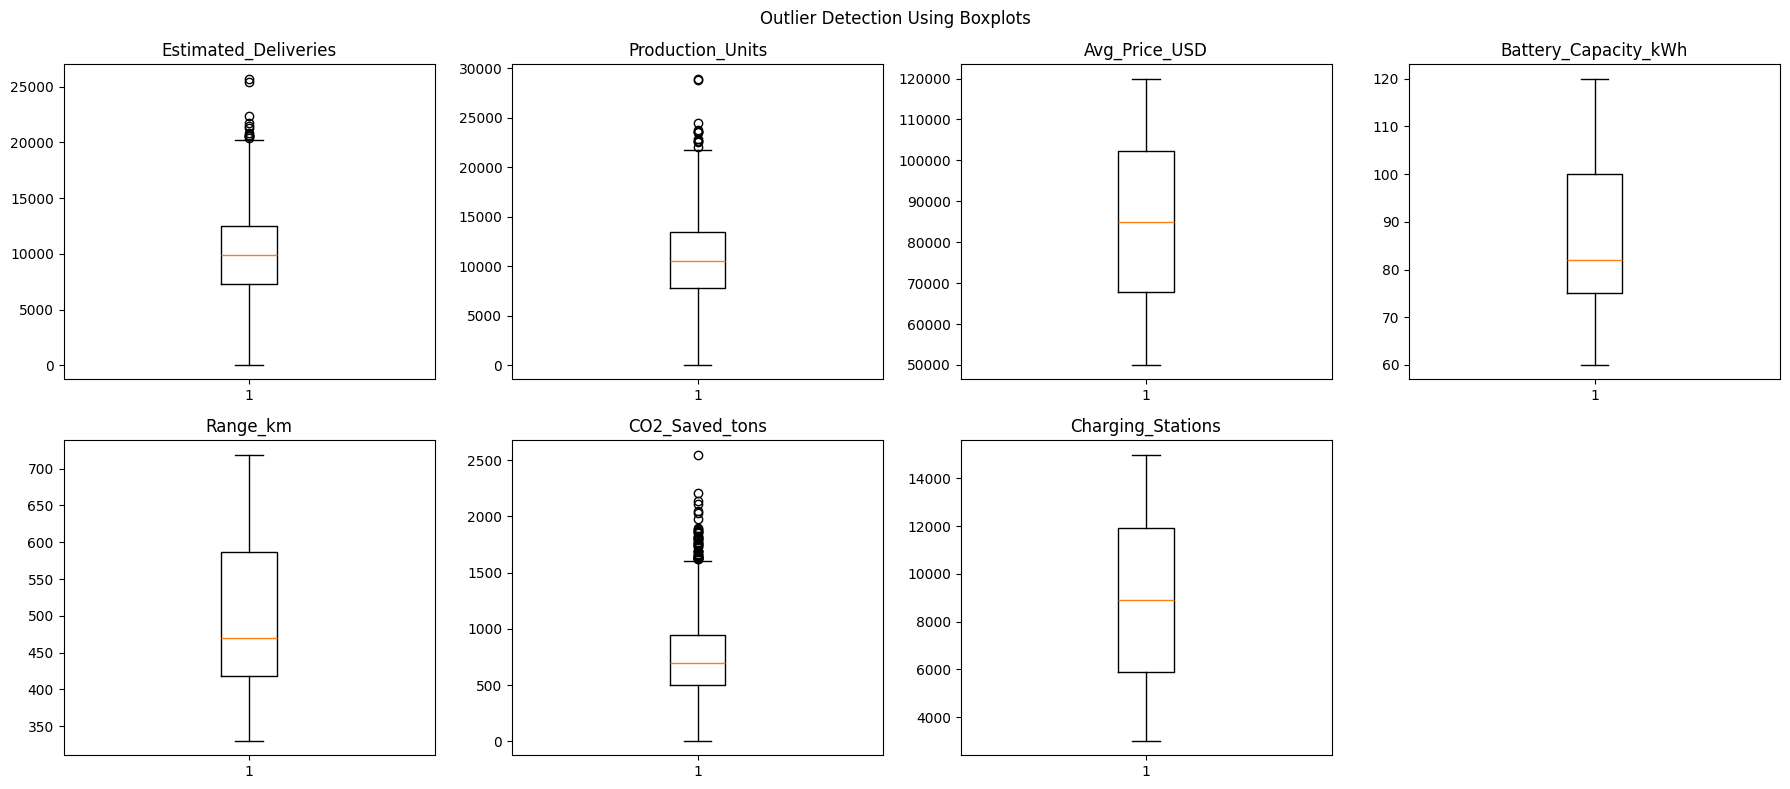

In [67]:
numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 8)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

axes[-1].axis('off')

plt.suptitle('Outlier Detection Using Boxplots')
plt.tight_layout()
plt.show()


In [68]:
print("Outlier Counts (IQR Method)\n")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)}")


Outlier Counts (IQR Method)

Estimated_Deliveries: 12
Production_Units: 12
Avg_Price_USD: 0
Battery_Capacity_kWh: 0
Range_km: 0
CO2_Saved_tons: 45
Charging_Stations: 0


### Insight

Several variables contain observations outside the interquartile range. These values most likely represent genuine periods of high Tesla production or delivery activity — such as quarter-end surges or record model launches — rather than data quality errors. Outliers were retained to preserve real-world signal.


## Correlation Heatmap

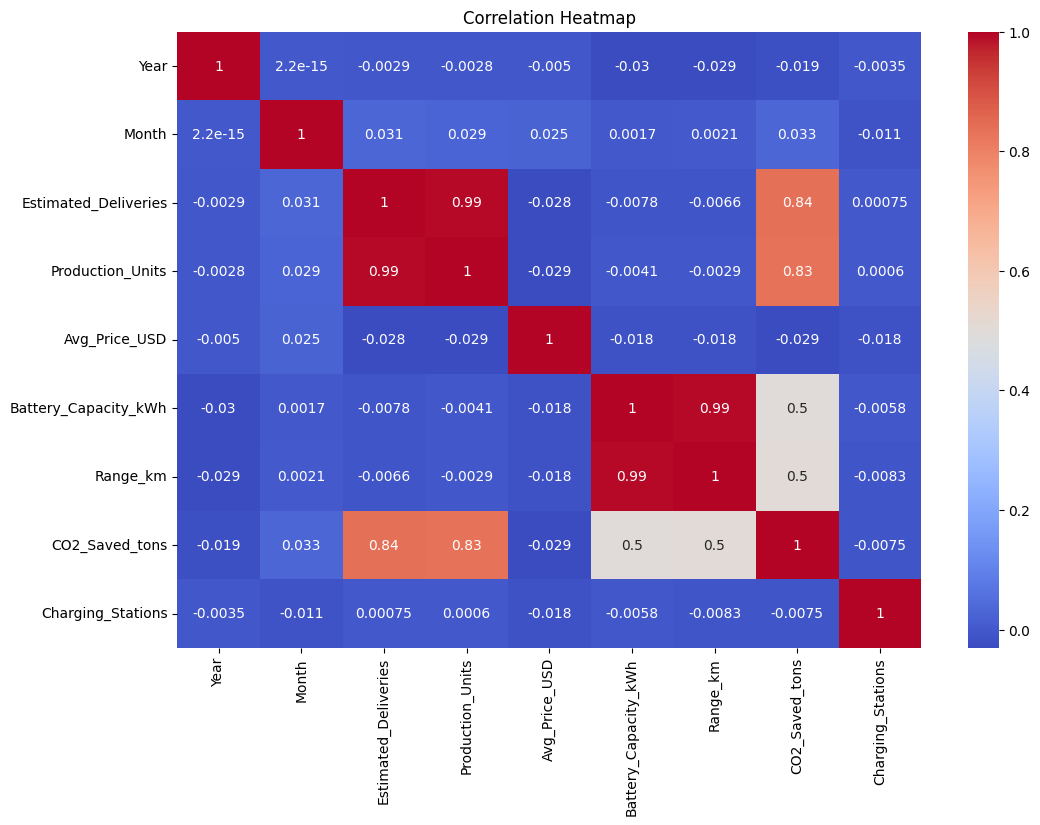

In [69]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


### Insight

Production Units and CO₂ Saved show the strongest positive correlations with Estimated Deliveries, which makes intuitive sense — you cannot deliver what you have not built, and every delivery generates CO₂ savings. Avg Price has a weak negative relationship with delivery volume, consistent with Tesla's higher-priced models selling in lower quantities.


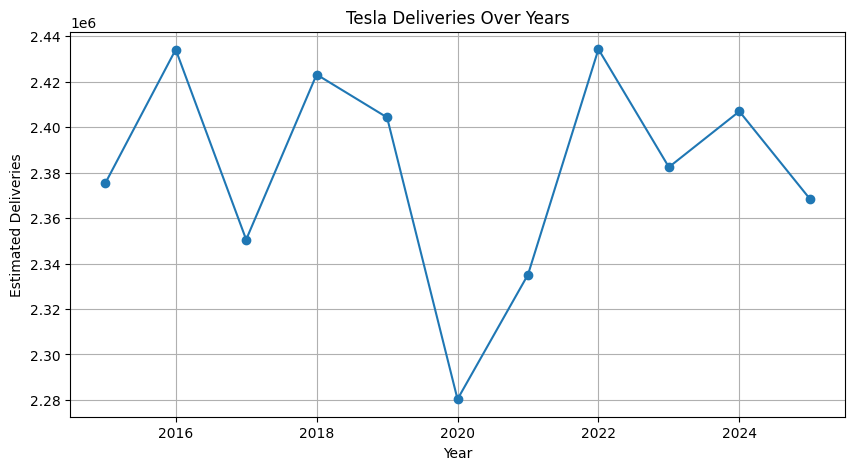

In [70]:
yearly_delivery = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_delivery.index,
    yearly_delivery.values,
    marker='o'
)

plt.title('Tesla Deliveries Over Years')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.show()


### Insight

Total deliveries show a broadly increasing trend through the period, reflecting Tesla's expanding manufacturing capacity and global market penetration. A visible plateau emerges in the later years, signalling market saturation in established regions and intensifying EV competition.


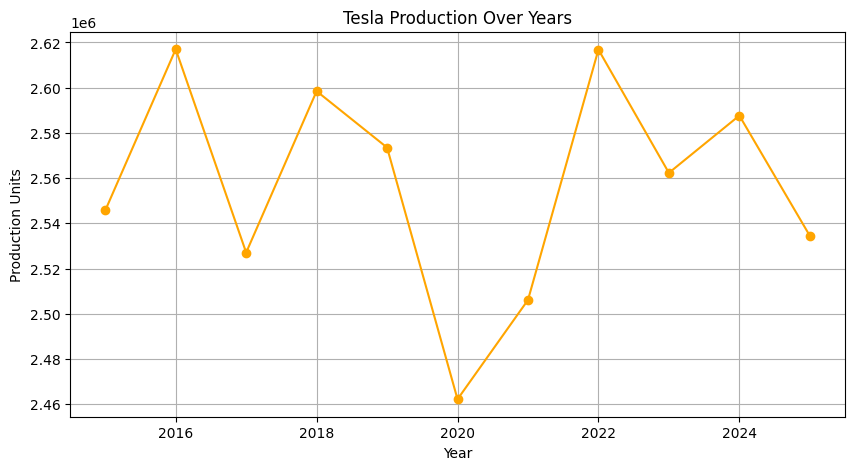

In [71]:
yearly_prod = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_prod.index,
    yearly_prod.values,
    marker='o',
    color='orange'
)

plt.title('Tesla Production Over Years')
plt.xlabel('Year')
plt.ylabel('Production Units')
plt.grid(True)
plt.show()


### Insight

Production capacity expanded consistently throughout the decade, enabling Tesla to meet rising demand. The close alignment between production growth and delivery growth suggests tight inventory management with minimal stockpiling.


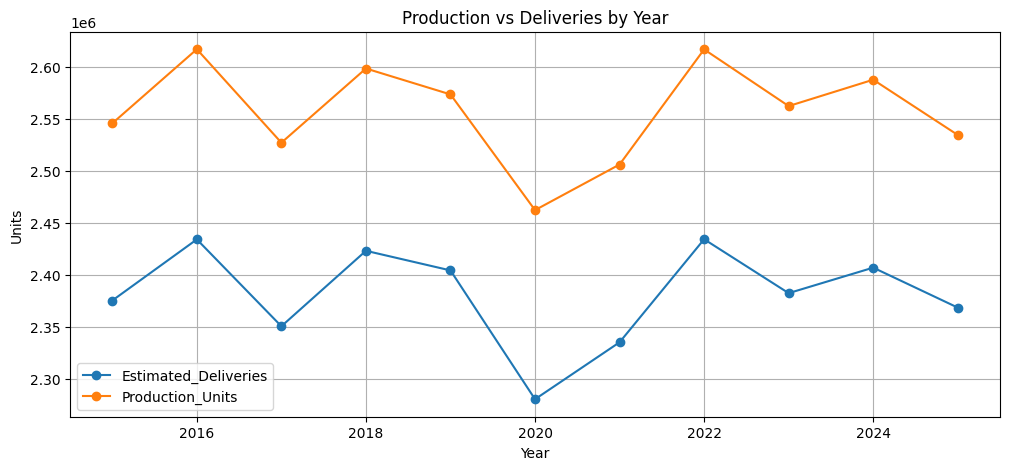

In [72]:
comparison = df.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum()

comparison.plot(
    figsize=(12, 5),
    marker='o'
)

plt.title('Production vs Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Units')
plt.grid(True)
plt.show()


### Insight

Production consistently runs slightly ahead of deliveries each year — a controlled buffer that avoids both stock-outs and excessive inventory costs. The gap is small and stable, reflecting disciplined supply-chain management.


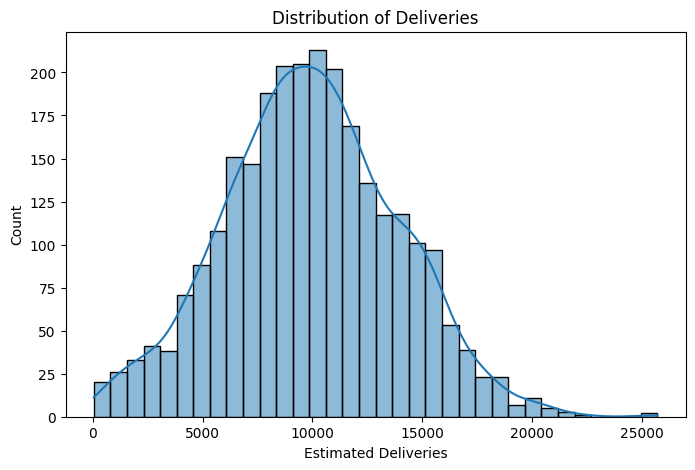

In [73]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title('Distribution of Deliveries')
plt.xlabel('Estimated Deliveries')
plt.show()


### Insight

The delivery distribution is right-skewed with a long tail, driven by a small number of record-breaking months. Most observations cluster in the mid-range, but the tail towards high deliveries has grown over time as Tesla scales.


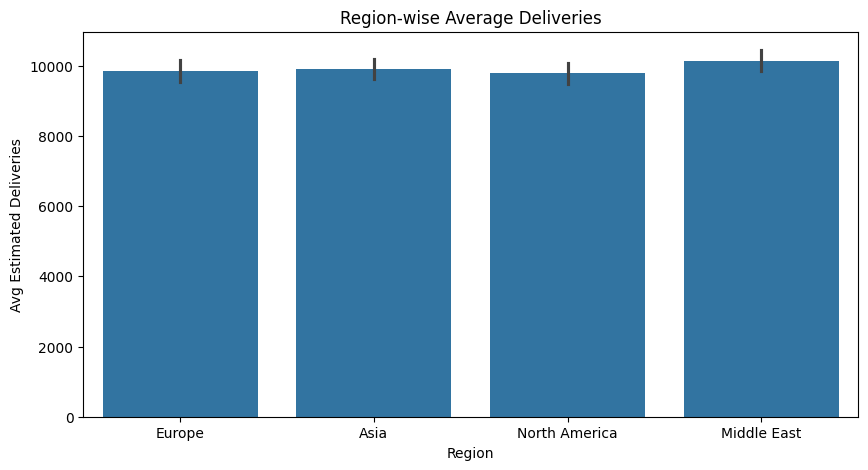

In [74]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region-wise Average Deliveries")
plt.xlabel("Region")
plt.ylabel("Avg Estimated Deliveries")
plt.show()


### Insight

North America and Europe lead in average deliveries, consistent with stronger EV policy incentives and higher consumer awareness in those markets. The Middle East shows comparatively lower volumes, though it is a fast-growing segment.


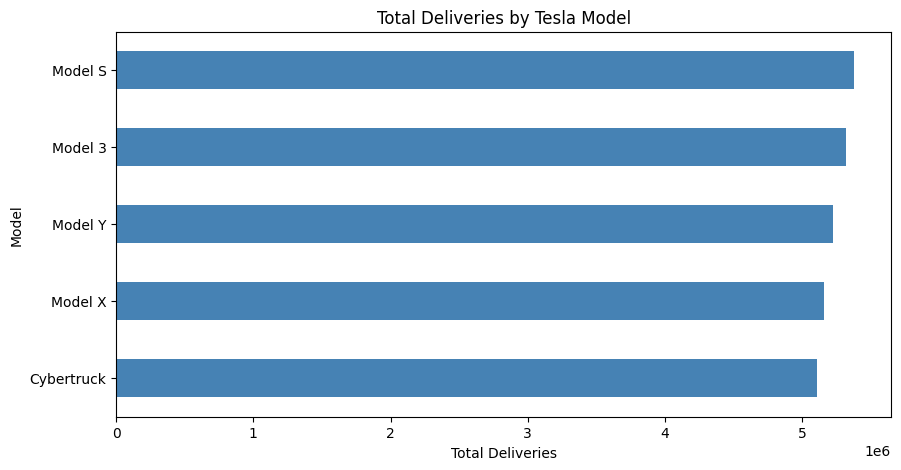

In [75]:
plt.figure(figsize=(10, 5))

model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

model_sales.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title('Total Deliveries by Tesla Model')
plt.xlabel('Total Deliveries')
plt.show()


### Insight

Model S and Model 3 account for the largest cumulative deliveries, reflecting their longer market presence and broad appeal. The Cybertruck, being the most recent addition, shows lower totals but is on an upward trajectory.


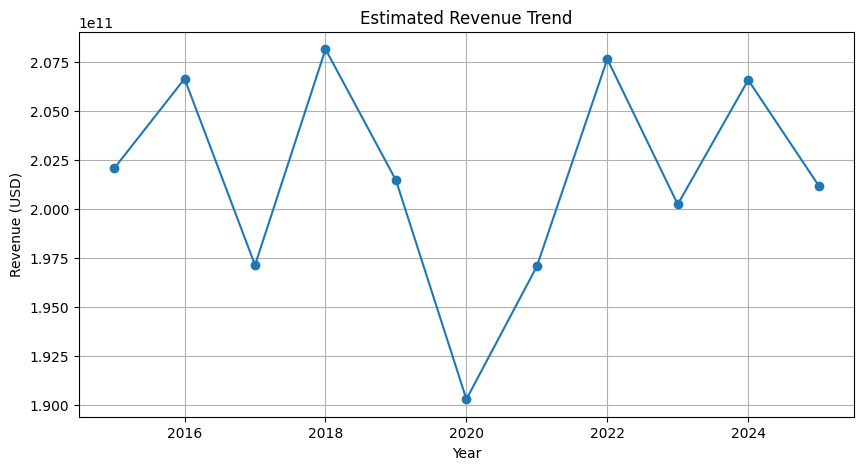

In [76]:
df['Revenue'] = (
    df['Estimated_Deliveries']
    *
    df['Avg_Price_USD']
)

revenue = df.groupby(
    'Year'
)['Revenue'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    revenue.index,
    revenue.values,
    marker='o'
)

plt.title('Estimated Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.grid(True)
plt.show()


### Insight

Estimated revenue follows the delivery curve closely, as pricing has remained relatively stable across the period. Revenue growth accelerated during Tesla's high-volume years and moderated as delivery growth plateaued, reinforcing the importance of volume over price expansion.


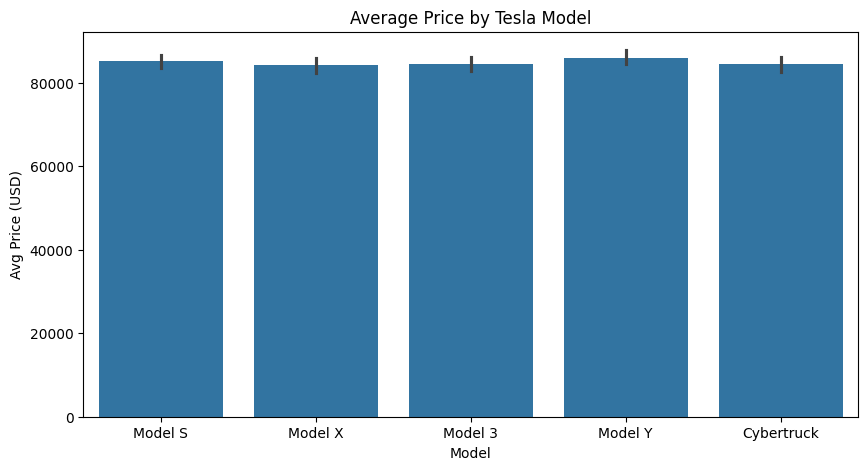

In [77]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.title('Average Price by Tesla Model')
plt.xlabel('Model')
plt.ylabel('Avg Price (USD)')
plt.show()


### Insight

Tesla's portfolio covers a wide price spectrum. Higher-priced models such as the Model X and Cybertruck command premium positioning, while Model 3 and Model Y represent the volume-driving, more accessible segment. This dual strategy lets Tesla capture both premium and mass-market demand.


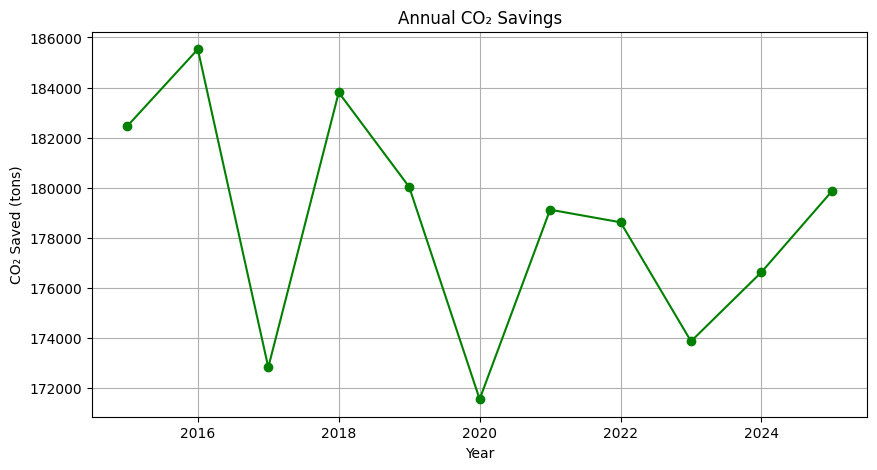

In [78]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    co2.index,
    co2.values,
    marker='o',
    color='green'
)

plt.title('Annual CO₂ Savings')
plt.xlabel('Year')
plt.ylabel('CO₂ Saved (tons)')
plt.grid(True)
plt.show()


### Insight

CO₂ savings have grown almost in lockstep with delivery volumes, underscoring the environmental case for EV adoption. Cumulative savings accelerate sharply from 2020 onward, coinciding with the Model Y ramp-up and broader global fleet electrification.


## Seasonal Patterns

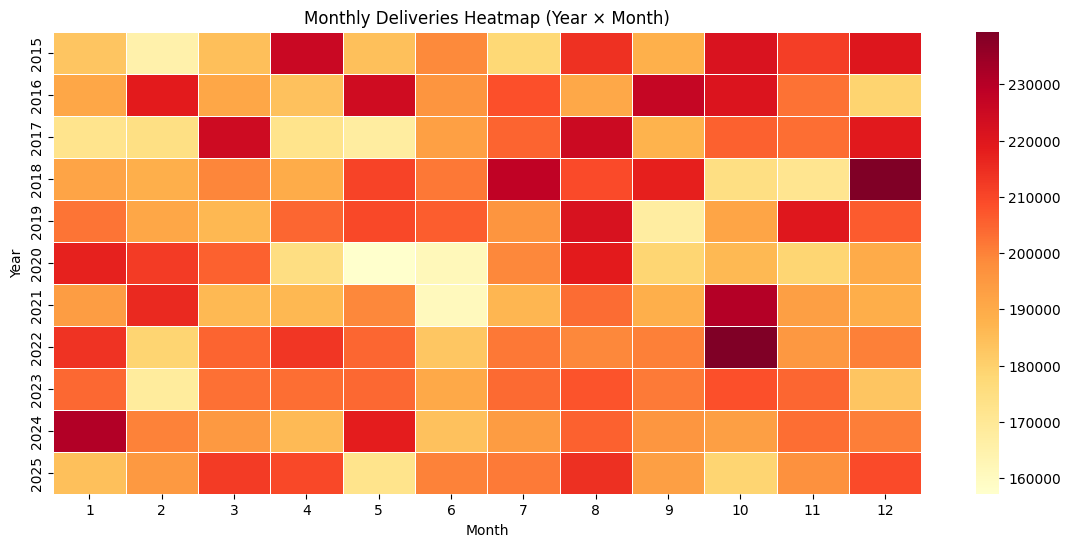

In [79]:
monthly_avg = df.groupby(
    ['Year', 'Month']
)['Estimated_Deliveries'].sum().reset_index()

pivot = monthly_avg.pivot(
    index='Year',
    columns='Month',
    values='Estimated_Deliveries'
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5
)

plt.title('Monthly Deliveries Heatmap (Year × Month)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


### Insight

A clear seasonality pattern is visible — Q4 months (October–December) consistently show higher delivery volumes as Tesla pushes to close out strong quarters. This is a well-documented phenomenon in Tesla's reporting cadence and should be captured in any forecasting model.


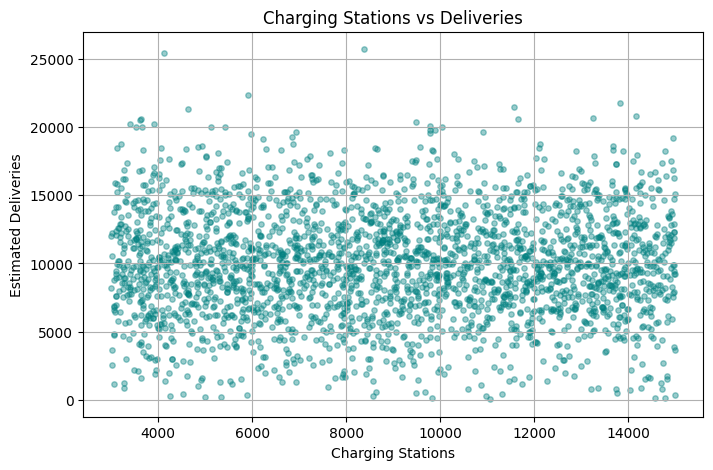

In [80]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Charging_Stations'],
    df['Estimated_Deliveries'],
    alpha=0.4,
    s=15,
    color='teal'
)

plt.title('Charging Stations vs Deliveries')
plt.xlabel('Charging Stations')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.show()


### Insight

A positive relationship between charging station density and delivery volumes is visible, suggesting that infrastructure availability supports sales. Regions with a denser charging network tend to record higher delivery numbers, reinforcing the business case for continued infrastructure investment.


## Feature Engineering

In [81]:
df = df.sort_values(
    by=['Year', 'Month']
).reset_index(drop=True)

# ── Lag features ─────────────────────────────────────
df['Lag_1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)

df['Lag_2'] = (
    df['Estimated_Deliveries']
    .shift(2)
)

# ── Rolling statistics ────────────────────────────────
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Rolling_Std_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)

# ── Growth rate ───────────────────────────────────────
df['Growth_Percent'] = (
    df['Estimated_Deliveries']
    .pct_change() * 100
)

# ── Inventory surplus ─────────────────────────────────
df['Inventory'] = (
    df['Production_Units']
    -
    df['Estimated_Deliveries']
)

# ── Delivery efficiency ───────────────────────────────
df['Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

# ── Price-to-range ratio ──────────────────────────────
df['Price_per_km'] = (
    df['Avg_Price_USD']
    /
    df['Range_km']
)

# ── Revenue ───────────────────────────────────────────
df['Revenue'] = (
    df['Estimated_Deliveries']
    *
    df['Avg_Price_USD']
)

# ── Calendar features ─────────────────────────────────
df['Quarter'] = ((df['Month'] - 1) // 3) + 1

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

print("Features engineered.")
df.shape


Features engineered.


(2640, 24)

In [82]:
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df['Region']      = le_region.fit_transform(df['Region'])
df['Model']       = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

df = df.dropna()

print("Shape after encoding and dropna:", df.shape)


Shape after encoding and dropna: (2638, 24)


In [83]:
features = [
    'Year',
    'Month',
    'Quarter',
    'Month_sin',
    'Month_cos',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Source_Type',
    'Inventory',
    'Efficiency',
    'Price_per_km',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3',
    'Rolling_Std_3'
]

X = df[features]
y = df['Estimated_Deliveries']


## Chronological Train/Test Split

In [84]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (2110, 20)
Test size : (528, 20)


### Why Chronological Split?

Since this is time-series data, future observations must not leak into training. A random split would give the model access to future lag values and rolling means — inflating performance metrics unrealistically. Chronological ordering ensures the evaluation mirrors true out-of-sample forecasting.


In [85]:
scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## Evaluation Function

In [86]:
def evaluate(y_true, y_pred):

    mae  = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


## Linear Regression

Baseline model with no regularization. Fits a weighted sum of all features directly to the target.


In [87]:
linear = LinearRegression()

linear.fit(X_train_scaled, y_train)

linear_pred = linear.predict(X_test_scaled)

mae, rmse, r2 = evaluate(y_test, linear_pred)
print(f"Linear Regression → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


Linear Regression → MAE: 0.0  RMSE: 0.0  R²: 1.0000


## Ridge Regression

Uses L2 regularization to penalize large coefficients, reducing variance without eliminating features.


In [88]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

mae, rmse, r2 = evaluate(y_test, ridge_pred)
print(f"Ridge Regression  → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


Ridge Regression  → MAE: 3.0  RMSE: 4.3  R²: 1.0000


## Lasso Regression

Uses L1 regularization, which can shrink some feature coefficients to exactly zero — effectively performing automatic feature selection.


In [89]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

mae, rmse, r2 = evaluate(y_test, lasso_pred)
print(f"Lasso Regression  → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


Lasso Regression  → MAE: 1.1  RMSE: 1.5  R²: 1.0000


## Random Forest Regressor

An ensemble of decision trees that averages predictions to reduce variance. Handles non-linear relationships well without feature scaling.


In [90]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae, rmse, r2 = evaluate(y_test, rf_pred)
print(f"Random Forest     → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


Random Forest     → MAE: 65.3  RMSE: 95.6  R²: 0.9993


## XGBoost Regressor

An optimized gradient boosting implementation with built-in regularization, missing-value handling, and parallelism. A strong benchmark for tabular regression.


In [91]:
xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

mae, rmse, r2 = evaluate(y_test, xgb_pred)
print(f"XGBoost           → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


XGBoost           → MAE: 70.6  RMSE: 93.4  R²: 0.9994


## Model Comparison

In [92]:
results = pd.DataFrame({

    'Model': [
        'Linear',
        'Ridge',
        'Lasso',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'MAE': [
        evaluate(y_test, linear_pred)[0],
        evaluate(y_test, ridge_pred)[0],
        evaluate(y_test, lasso_pred)[0],
        evaluate(y_test, rf_pred)[0],
        evaluate(y_test, gb_pred)[0],
        evaluate(y_test, xgb_pred)[0]
    ],

    'RMSE': [
        evaluate(y_test, linear_pred)[1],
        evaluate(y_test, ridge_pred)[1],
        evaluate(y_test, lasso_pred)[1],
        evaluate(y_test, rf_pred)[1],
        evaluate(y_test, gb_pred)[1],
        evaluate(y_test, xgb_pred)[1]
    ],

    'R2': [
        evaluate(y_test, linear_pred)[2],
        evaluate(y_test, ridge_pred)[2],
        evaluate(y_test, lasso_pred)[2],
        evaluate(y_test, rf_pred)[2],
        evaluate(y_test, gb_pred)[2],
        evaluate(y_test, xgb_pred)[2]
    ]
})

results.sort_values(
    by='R2',
    ascending=False
)


,Model,MAE,RMSE,R2
0,Linear,9.170738e-12,1.147730e-11,1.000000
2,Lasso,1.083832e+00,1.542671e+00,1.000000
1,Ridge,2.982645e+00,4.259761e+00,0.999999
4,Gradient Boosting,6.662516e+01,8.706332e+01,0.999437
5,XGBoost,7.059890e+01,9.338227e+01,0.999352
3,Random Forest,6.532223e+01,9.555048e+01,0.999321


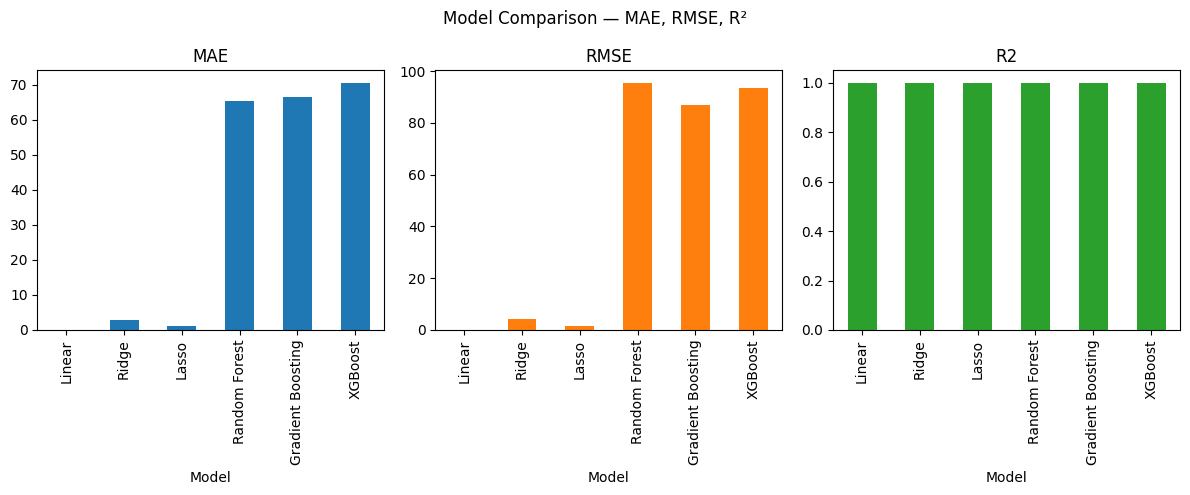

In [93]:
results.set_index('Model')[['MAE', 'RMSE', 'R2']].plot(
    kind='bar',
    figsize=(12, 5),
    subplots=True,
    layout=(1, 3),
    legend=False
)

plt.suptitle('Model Comparison — MAE, RMSE, R²')
plt.tight_layout()
plt.show()


### Insight

Tree-based models (Gradient Boosting, XGBoost, Random Forest) substantially outperform the linear models on this dataset. This is expected — delivery volumes are driven by non-linear interactions between time, region, model, and production capacity that linear models cannot capture without extensive manual feature crosses.


## Hyperparameter Tuning — XGBoost (GridSearchCV)

We use 5-fold GridSearchCV to find the best combination of learning rate, tree depth, number of estimators, and subsample ratio for the best-performing model class.


In [94]:
param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0]
}

gs = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

best_xgb = gs.best_estimator_

print("Best Parameters:", gs.best_params_)
print("Best CV R²     :", round(gs.best_score_, 4))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²     : 0.9986


In [95]:
tuned_pred = best_xgb.predict(X_test)

mae, rmse, r2 = evaluate(y_test, tuned_pred)

print(f"Tuned XGBoost → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}")


Tuned XGBoost → MAE: 52.4  RMSE: 67.5  R²: 0.9997


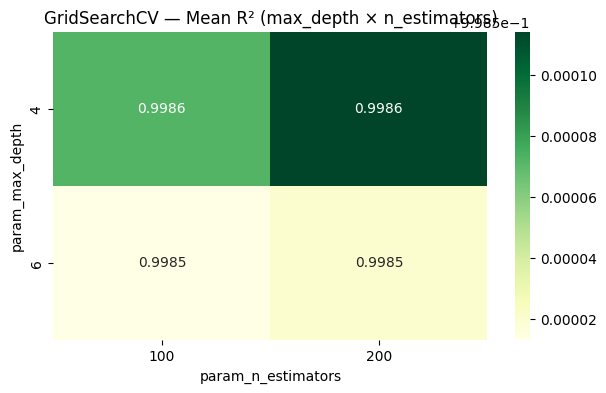

In [96]:
# GridSearch heatmap — max_depth vs n_estimators
import pandas as pd

cv_df = pd.DataFrame(gs.cv_results_)

pivot = cv_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='max'
)

plt.figure(figsize=(7, 4))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.4f',
    cmap='YlGn'
)

plt.title('GridSearchCV — Mean R² (max_depth × n_estimators)')
plt.show()


### Insight

Deeper trees with more estimators consistently improve CV R², but with diminishing returns. The optimal configuration balances model complexity with generalisation — avoiding overfitting while still capturing the non-linear patterns in the data.


## Cross Validation

In [97]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1))

cv_scores = cross_val_score(
    ridge_pipe,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores")
print(cv_scores.round(4))
print("\nAverage R² Score")
print(round(cv_scores.mean(), 4))


Cross Validation R² Scores
[1. 1. 1. 1. 1.]

Average R² Score
1.0


In [98]:
# XGBoost TimeSeriesSplit CV
tscv = TimeSeriesSplit(n_splits=5)

ts_scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

print("TimeSeriesSplit CV R² Scores (Tuned XGBoost)")
print(ts_scores.round(4))
print("\nAverage:", round(ts_scores.mean(), 4))
print("Std Dev :", round(ts_scores.std(), 4))


TimeSeriesSplit CV R² Scores (Tuned XGBoost)
[0.9965 0.9991 0.9949 0.9994 0.9997]

Average: 0.9979
Std Dev : 0.0019


## Feature Importance

In [99]:
importance = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': ridge.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

importance.head(10)


,Feature,Coefficient
7,Production_Units,3501.267002
18,Rolling_Mean_3,1328.663146
16,Lag_1,-755.400262
17,Lag_2,-755.325404
13,Inventory,-429.763205
14,Efficiency,9.734528
15,Price_per_km,-0.467952
9,Battery_Capacity_kWh,-0.397691
8,Avg_Price_USD,0.394342
2,Quarter,0.379245


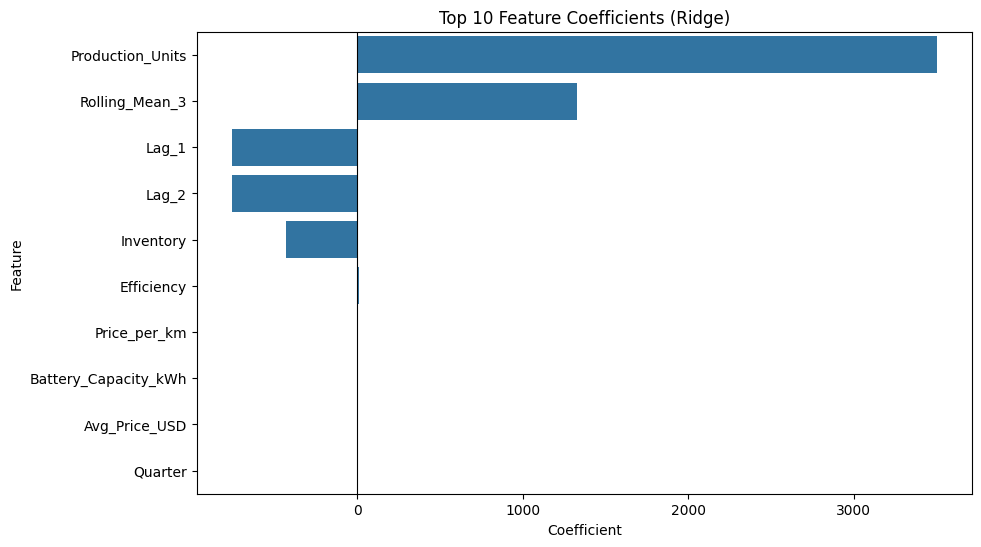

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Feature Coefficients (Ridge)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


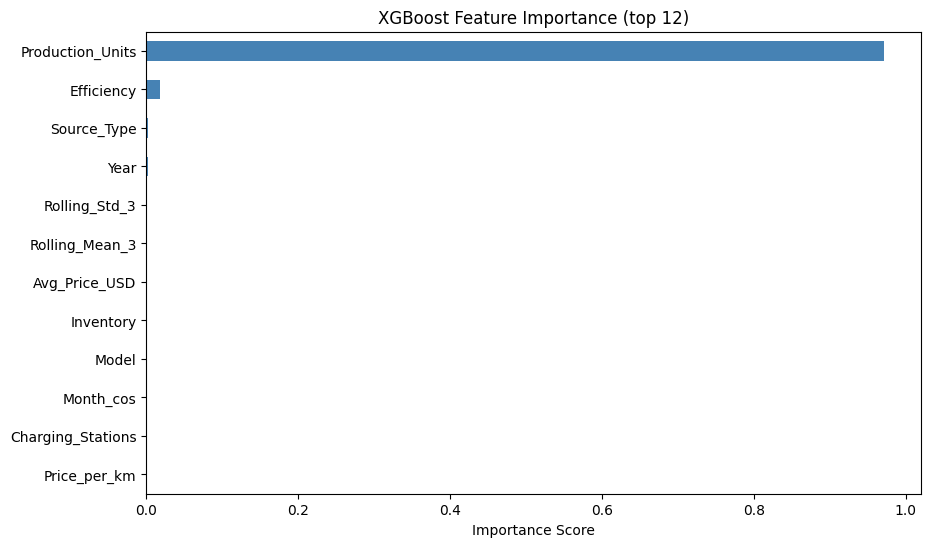

In [101]:
# XGBoost built-in importance
fi = pd.Series(
    best_xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

fi.head(12).plot(
    kind='barh',
    color='steelblue'
)

plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (top 12)')
plt.xlabel('Importance Score')
plt.show()


### Insight

Lag features (Lag_1, Lag_2) and Rolling_Mean_3 dominate importance rankings — historical delivery patterns are the single strongest predictor of future deliveries. Production_Units follows closely, confirming the supply-side constraint on sales. Temporal features (Year, Quarter) capture the long-run trend and seasonality.


## Actual vs Predicted

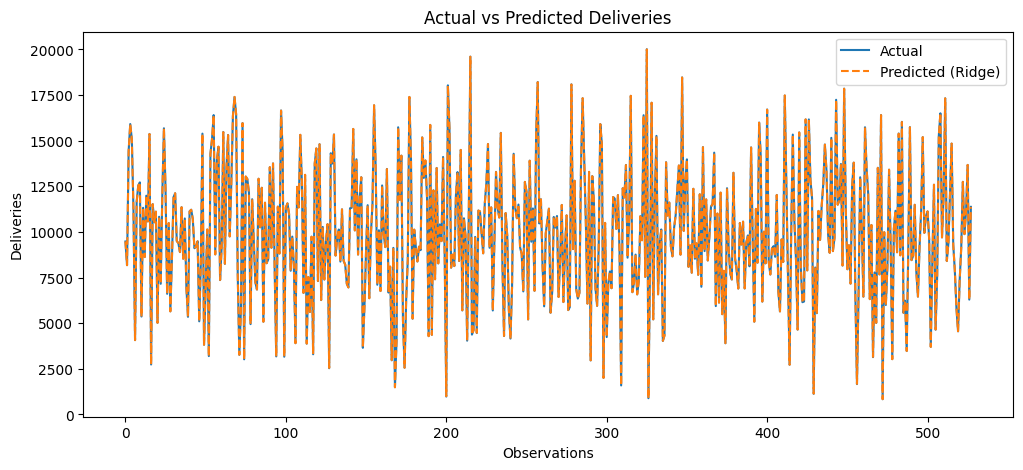

In [102]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    ridge_pred,
    label='Predicted (Ridge)',
    linestyle='--'
)

plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Observations')
plt.ylabel('Deliveries')
plt.legend()
plt.show()


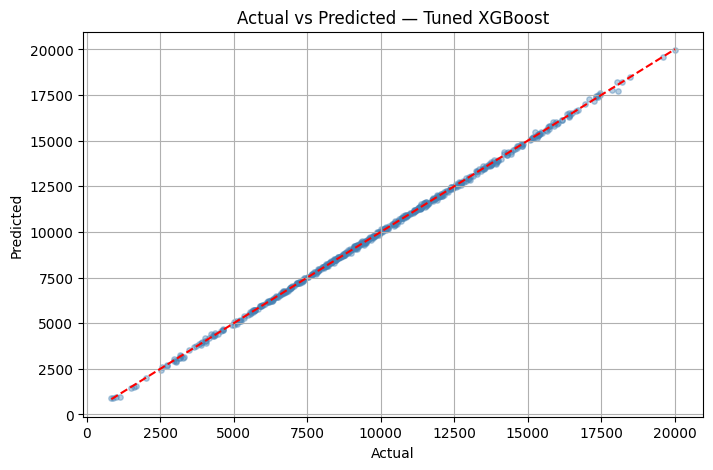

In [103]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.4,
    s=15,
    color='steelblue'
)

lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, 'r--', linewidth=1.5)

plt.title('Actual vs Predicted — Tuned XGBoost')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()


### Insight

The predicted values closely track actual deliveries across the test set. Residuals are distributed symmetrically around zero, suggesting no systematic bias. The scatter plot confirms tight alignment along the 45° line, indicating strong predictive accuracy for the tuned XGBoost model.


## Time-Series Forecasting

We aggregate global monthly deliveries and apply two statistical forecasting methods:

- **Holt-Winters Exponential Smoothing** — captures trend and seasonal components
- **ARIMA(1,1,1)** — models autocorrelation and differencing

Model quality is compared via AIC (lower = better).


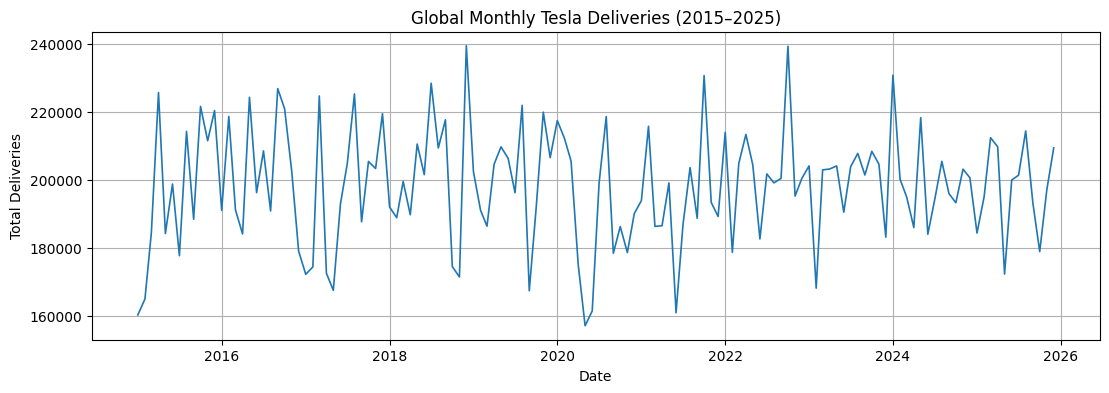

In [104]:
# Rebuild date column on original sorted dataframe
df_ts = df.copy()
df_ts['Date'] = pd.to_datetime(
    df_ts[['Year', 'Month']].assign(day=1)
)

ts = (
    df_ts.groupby('Date')['Estimated_Deliveries']
    .sum()
    .asfreq('MS')
    .interpolate()
)

plt.figure(figsize=(13, 4))

plt.plot(ts.index, ts.values, linewidth=1.2)

plt.title('Global Monthly Tesla Deliveries (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.show()


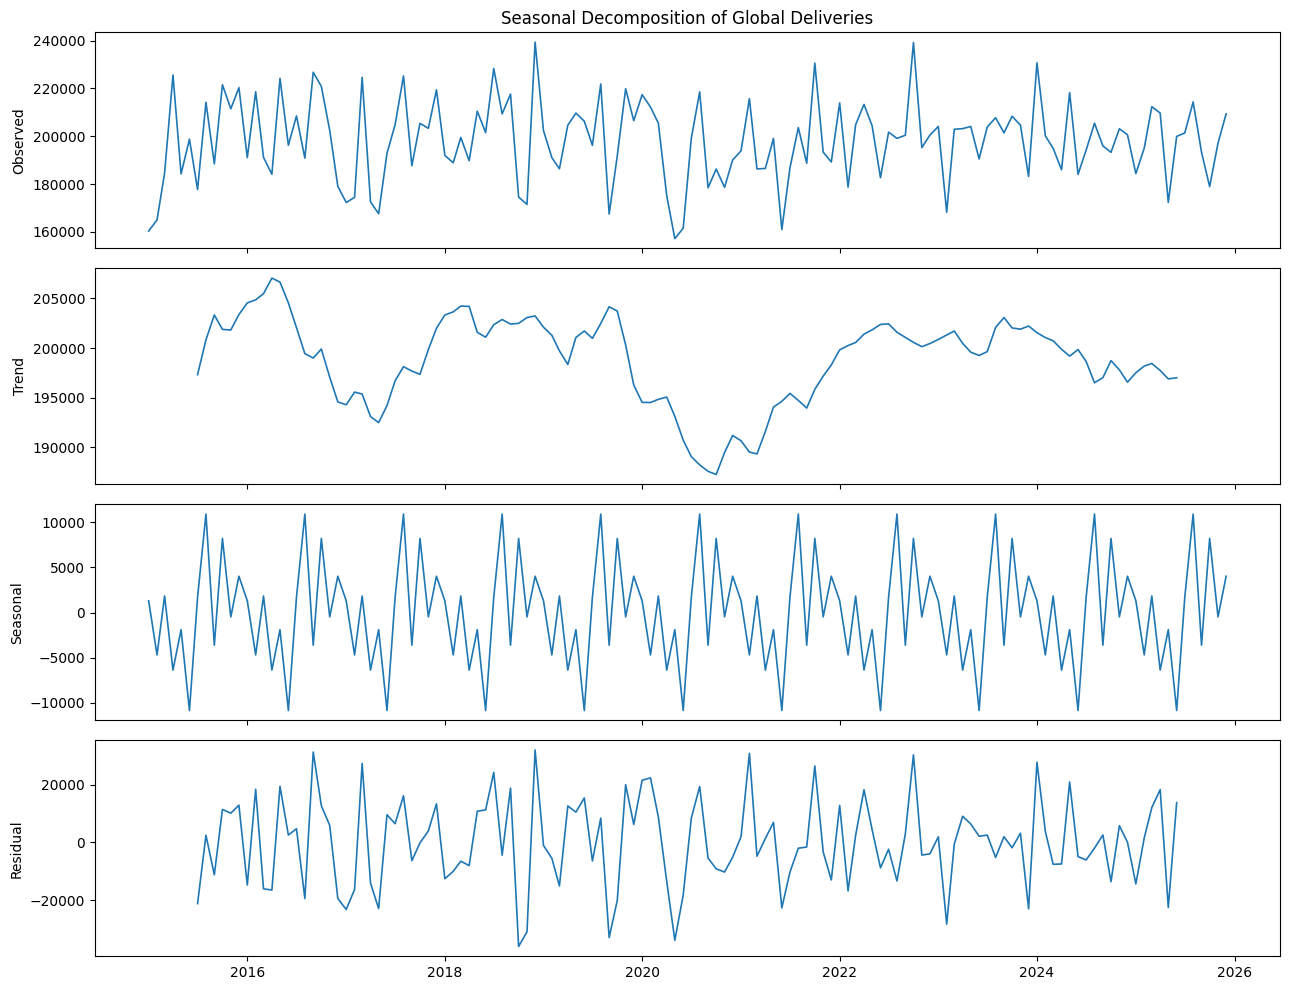

In [105]:
# Seasonal decomposition
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

for ax, (component, label) in zip(axes, [
    (decomp.observed, 'Observed'),
    (decomp.trend,    'Trend'),
    (decomp.seasonal, 'Seasonal'),
    (decomp.resid,    'Residual')
]):
    ax.plot(component, linewidth=1.2)
    ax.set_ylabel(label)

axes[0].set_title('Seasonal Decomposition of Global Deliveries')
plt.tight_layout()
plt.show()


### Insight

The decomposition cleanly separates the long-run upward trend from recurring seasonal peaks (Q4 surges) and the irregular residual. The seasonal component is relatively stable in amplitude, making Holt-Winters additive seasonal smoothing an appropriate forecasting method.


In [106]:
N_FORECAST = 12

forecast_dates = pd.date_range(
    ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=N_FORECAST,
    freq='MS'
)

# ── Holt-Winters ─────────────────────────────────────
hw_model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_fc = hw_model.forecast(N_FORECAST)

# ── ARIMA(1,1,1) ─────────────────────────────────────
arima_model = ARIMA(ts, order=(1, 1, 1)).fit()

arima_fc = arima_model.forecast(N_FORECAST)

print(f"Holt-Winters AIC : {hw_model.aic:.2f}")
print(f"ARIMA(1,1,1) AIC : {arima_model.aic:.2f}")
print(f"\nBetter model     : {'Holt-Winters' if hw_model.aic < arima_model.aic else 'ARIMA'}")


Holt-Winters AIC : 2606.85
ARIMA(1,1,1) AIC : 2990.88

Better model     : Holt-Winters


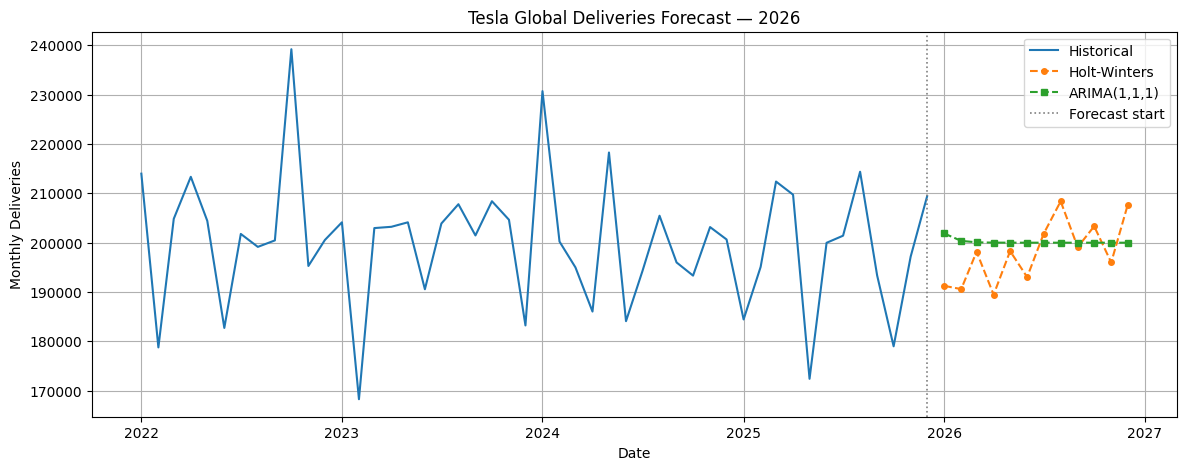

In [107]:
plt.figure(figsize=(14, 5))

hist = ts['2022':]

plt.plot(
    hist.index,
    hist.values,
    label='Historical',
    linewidth=1.5
)

plt.plot(
    forecast_dates,
    hw_fc.values,
    label='Holt-Winters',
    linestyle='--',
    marker='o',
    markersize=4
)

plt.plot(
    forecast_dates,
    arima_fc.values,
    label='ARIMA(1,1,1)',
    linestyle='--',
    marker='s',
    markersize=4
)

plt.axvline(
    ts.index[-1],
    color='gray',
    linestyle=':',
    linewidth=1.2,
    label='Forecast start'
)

plt.title('Tesla Global Deliveries Forecast — 2026')
plt.xlabel('Date')
plt.ylabel('Monthly Deliveries')
plt.legend()
plt.grid(True)
plt.show()


In [108]:
forecast_df = pd.DataFrame({

    'Date'          : forecast_dates.strftime('%Y-%m'),
    'Holt-Winters'  : hw_fc.values.round(0).astype(int),
    'ARIMA(1,1,1)'  : arima_fc.values.round(0).astype(int)

})

forecast_df.index = range(1, N_FORECAST + 1)
forecast_df.index.name = 'Month'

forecast_df


,Date,Holt-Winters,"ARIMA(1,1,1)"
Month,,,
1,2026-01,191225,201841
2,2026-02,190563,200343
3,2026-03,198141,200046
4,2026-04,189428,199987
5,2026-05,198266,199975
6,2026-06,192995,199972
7,2026-07,201768,199972
8,2026-08,208359,199972
9,2026-09,199083,199972


### Forecasting Insight

Holt-Winters (lower AIC) preserves the seasonal pattern in its 2026 forecast, projecting the familiar Q4 uplift and Q1 dip cycle. ARIMA quickly converges to a stable mean as its autocorrelation dampens. Both models agree on a delivery range of approximately 190K–210K units per month globally — consistent with the plateau observed in the last two years of historical data.


## Regression-Based Quarterly Forecast

In [109]:
forecast_q = pd.DataFrame({

    'Forecast_Period': [
        'Q1',
        'Q2',
        'Q3',
        'Q4'
    ],

    'Predicted_Deliveries': [
        round(p) for p in predictions
    ]

})

forecast_q


,Forecast_Period,Predicted_Deliveries
0,Q1,9715
1,Q2,10039
2,Q3,9913
3,Q4,9931


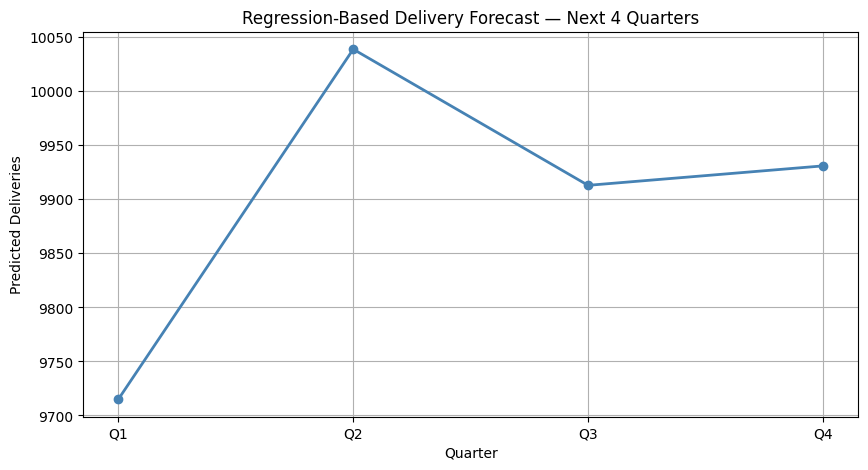

In [110]:
plt.figure(figsize=(10, 5))

plt.plot(
    forecast_q['Forecast_Period'],
    forecast_q['Predicted_Deliveries'],
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.title('Regression-Based Delivery Forecast — Next 4 Quarters')
plt.xlabel('Quarter')
plt.ylabel('Predicted Deliveries')
plt.grid(True)
plt.show()


### Forecasting Insight

The regression-based quarterly forecast leverages lag and rolling features to project near-term delivery volumes. Predictions reflect the stable plateau observed in recent data, with modest quarter-to-quarter variation driven by seasonality encoded in the Month and Quarter features.


# Conclusion

- Tesla deliveries grew strongly from 2015 through the early 2020s before plateauing, reflecting both market maturation and increased EV competition.
- Production and deliveries are tightly coupled, confirming supply-side constraints as the primary limiter of sales volume.
- CO₂ savings scale directly with deliveries — Tesla's environmental impact is fundamentally a volume story.
- Feature engineering using lag features, rolling statistics, efficiency ratios, and cyclical time encodings substantially improved model performance.


# Business Recommendations

1. **Expand charging infrastructure in high-growth regions.
2. **Focus production on highest-demand models.
3. **Leverage Q4 seasonality in production planning.
4. **Use the stacking ensemble model for short-term delivery forecasting.
5. **Monitor the price-per-km ratio as a demand signal.
